In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install jiwer pandas numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 110.4 MB/s eta 0:00:00


In [3]:
from google.colab import files
uploaded = files.upload()

Saving Q4.csv to Q4.csv


In [4]:
import pandas as pd
import numpy as np
import re
from collections import Counter

# Load CSV
df = pd.read_csv('Q4.csv')

# Drop any fully empty trailing columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst row:")
df.head(2)

Shape: (46, 8)

Columns: ['segment_url_link', 'Human', 'Model H', 'Model i', 'Model k', 'Model l', 'Model m', 'Model n']

First row:


,segment_url_link,Human,Model H,Model i,Model k,Model l,Model m,Model n
0,https://storage.googleapis.com/testing_audio_f...,वही अपना खेती बाड़ी और क्या,वही अपना खेती बाड़ी और क्या,वही अपना खेती बाड़ी और क्या,वही अपना खेती बाड़ी और क्या?,वही अपना खेती बाड़ी और क्या,वही अपना खेतीबाड़ी और क्या,वही अपना खेती बाड़ी और क्या
1,https://storage.googleapis.com/testing_audio_f...,मौनता का अर्थ क्या होता है,मौनता का अर्थ क्या होता है,मौनता का अर्थ क्या होता है?,मौन तागार थके होतई।,मोनता का अर्थ है क्या होता है,मोन ताका हर थक्या होताहए,मौनता का हर थका होता है


In [5]:
def normalize(text):
    """Normalize ASR text for fair comparison."""
    if not isinstance(text, str):
        return ""
    # Remove punctuation characters (keep Devanagari, spaces, Roman letters, digits)
    text = re.sub(r'[।॥\.\?\!\,\;\:\'\"\-\–\—\.]{1,}', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase Roman script portions only
    text = re.sub(r'[a-zA-Z]+', lambda m: m.group().lower(), text)
    return text

# Define model columns
MODEL_COLS = ['Model H', 'Model i', 'Model k', 'Model l', 'Model m', 'Model n']
REFERENCE_COL = 'Human'

# Apply normalization
df['ref_norm'] = df[REFERENCE_COL].apply(normalize)
for col in MODEL_COLS:
    df[f'{col}_norm'] = df[col].apply(normalize)

# Preview normalization
print("=== Normalization Preview ===")
for i in range(3):
    print(f"\n--- Row {i} ---")
    print(f"  Original Ref : {df[REFERENCE_COL].iloc[i]}")
    print(f"  Normalized   : {df['ref_norm'].iloc[i]}")
    print(f"  Model H orig : {df['Model H'].iloc[i]}")
    print(f"  Model H norm : {df['Model H_norm'].iloc[i]}")

=== Normalization Preview ===

--- Row 0 ---
  Original Ref : वही अपना खेती बाड़ी और क्या
  Normalized   : वही अपना खेती बाड़ी और क्या
  Model H orig : वही अपना खेती बाड़ी और क्या
  Model H norm : वही अपना खेती बाड़ी और क्या

--- Row 1 ---
  Original Ref : मौनता का अर्थ क्या होता है
  Normalized   : मौनता का अर्थ क्या होता है
  Model H orig : मौनता का अर्थ क्या होता है
  Model H norm : मौनता का अर्थ क्या होता है

--- Row 2 ---
  Original Ref : और रक्षाबंधन पे चलो बहनों को
  Normalized   : और रक्षाबंधन पे चलो बहनों को
  Model H orig : और रक्षाबंधन पे चलो बहनों को
  Model H norm : और रक्षाबंधन पे चलो बहनों को


In [6]:
def word_edit_distance(ref_words, hyp_words):
    """
    Compute word-level edit distance using dynamic programming.
    Returns (distance, substitutions, insertions, deletions, alignment)
    alignment: list of (ref_word_or_None, hyp_word_or_None, op)
               op in {'match', 'sub', 'ins', 'del'}
    """
    n, m = len(ref_words), len(hyp_words)
    # dp[i][j] = (cost, operation)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1): dp[i][0] = i
    for j in range(m + 1): dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref_words[i-1] == hyp_words[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j-1],  # substitution
                                   dp[i][j-1],      # insertion
                                   dp[i-1][j])      # deletion

    # Traceback to get alignment
    alignment = []
    i, j = n, m
    S = I = D = 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and ref_words[i-1] == hyp_words[j-1]:
            alignment.append((ref_words[i-1], hyp_words[j-1], 'match'))
            i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
            alignment.append((ref_words[i-1], hyp_words[j-1], 'sub'))
            S += 1; i -= 1; j -= 1
        elif j > 0 and dp[i][j] == dp[i][j-1] + 1:
            alignment.append((None, hyp_words[j-1], 'ins'))
            I += 1; j -= 1
        else:
            alignment.append((ref_words[i-1], None, 'del'))
            D += 1; i -= 1

    alignment.reverse()
    return dp[n][m], S, I, D, alignment


def compute_wer(reference, hypothesis):
    """Compute WER between two normalized strings."""
    ref_words = reference.split()
    hyp_words = hypothesis.split()
    if len(ref_words) == 0:
        return 0.0 if len(hyp_words) == 0 else 1.0
    dist, S, I, D, alignment = word_edit_distance(ref_words, hyp_words)
    wer = (S + I + D) / len(ref_words)
    return wer


print("WER functions defined.")
# Quick sanity check
r = "वही अपना खेती बाड़ी और क्या"
h = "वही अपना खेतीबाड़ी और क्या"
print(f"Sanity check WER: {compute_wer(r, h):.3f}  (expected ~0.167 for 1 sub in 6 words)")

WER functions defined.
Sanity check WER: 0.333  (expected ~0.167 for 1 sub in 6 words)


In [7]:
AGREEMENT_THRESHOLD = 3  # out of 6 models; majority = trusted

def build_lattice(ref_words, model_outputs_words, threshold=AGREEMENT_THRESHOLD):
    """
    Build a lattice from reference and multiple model outputs.

    Returns:
        lattice: list of dicts, one per reference position
            {
              'ref_word': str,
              'valid_words': set of str,   # includes ref + valid alternatives
              'optional': bool             # True if this position can be skipped
            }
        insertion_bins: dict mapping (position, inserted_word) -> count
            for insertions agreed upon by >= threshold models
    """
    N = len(ref_words)
    lattice = [
        {'ref_word': ref_words[i], 'valid_words': {ref_words[i]}, 'optional': False}
        for i in range(N)
    ]

    # Track per-position: what each model produced
    # position_votes[i] = list of words models placed at position i
    position_votes = [[] for _ in range(N)]
    deletion_votes = [0] * N  # how many models deleted ref word at pos i

    # Track insertions: (after_position, word) -> count
    insertion_votes = Counter()

    for hyp_words in model_outputs_words:
        if not hyp_words:
            continue
        _, S, I, D, alignment = word_edit_distance(ref_words, hyp_words)

        ref_pos = 0
        for (rw, hw, op) in alignment:
            if op == 'match':
                position_votes[ref_pos].append(hw)
                ref_pos += 1
            elif op == 'sub':
                position_votes[ref_pos].append(hw)
                ref_pos += 1
            elif op == 'del':
                deletion_votes[ref_pos] += 1
                ref_pos += 1
            elif op == 'ins':
                # Record insertion after current ref_pos (clamped)
                ins_key = (min(ref_pos, N-1), hw)
                insertion_votes[ins_key] += 1

    # Apply substitution alternatives
    for i in range(N):
        word_counts = Counter(position_votes[i])
        for word, count in word_counts.items():
            if count >= threshold:
                lattice[i]['valid_words'].add(word)

    # Apply deletion optionality
    for i in range(N):
        if deletion_votes[i] >= threshold:
            lattice[i]['optional'] = True

    # Collect agreed insertions
    agreed_insertions = {
        k: v for k, v in insertion_votes.items() if v >= threshold
    }

    return lattice, agreed_insertions


print("Lattice builder defined.")

# === Demo on first row ===
row = df.iloc[1]  # pick a row with visible differences
ref_w = row['ref_norm'].split()
model_outputs_w = [row[f'{c}_norm'].split() for c in MODEL_COLS]

lattice, ins = build_lattice(ref_w, model_outputs_w)

print(f"\n=== Demo Lattice (Row 1) ===")
print(f"Reference: {row['ref_norm']}\n")
for i, bin_ in enumerate(lattice):
    flag = " [OPTIONAL]" if bin_['optional'] else ""
    alts = bin_['valid_words'] - {bin_['ref_word']}
    alts_str = f" | alternatives: {alts}" if alts else ""
    print(f"  Bin {i:2d}: '{bin_['ref_word']}'{alts_str}{flag}")
if ins:
    print(f"\nAgreed insertions: {ins}")

Lattice builder defined.

=== Demo Lattice (Row 1) ===
Reference: मौनता का अर्थ क्या होता है

  Bin  0: 'मौनता'
  Bin  1: 'का'
  Bin  2: 'अर्थ'
  Bin  3: 'क्या'
  Bin  4: 'होता'
  Bin  5: 'है'


In [8]:
def lattice_edit_distance(lattice, hyp_words, agreed_insertions):
    """
    Compute edit distance between a hypothesis and a lattice.
    A match occurs when hyp word is in bin['valid_words'].
    Optional bins don't penalize deletions.
    Returns (S, I, D, lattice_len)
    """
    N = len(lattice)
    M = len(hyp_words)

    # Build cost matrix
    # dp[i][j] = min cost aligning lattice[0..i-1] with hyp[0..j-1]
    INF = float('inf')
    dp = [[INF] * (M + 1) for _ in range(N + 1)]
    dp[0][0] = 0

    for i in range(1, N + 1):
        del_cost = 0 if lattice[i-1]['optional'] else 1
        dp[i][0] = dp[i-1][0] + del_cost

    for j in range(1, M + 1):
        dp[0][j] = dp[0][j-1] + 1  # insertion

    for i in range(1, N + 1):
        bin_ = lattice[i-1]
        del_cost = 0 if bin_['optional'] else 1
        for j in range(1, M + 1):
            hyp_word = hyp_words[j-1]

            # Check if insertion is agreed upon
            ins_key = (i-1, hyp_word)
            ins_cost = 0 if ins_key in agreed_insertions else 1

            # Match: hyp word is in bin's valid set
            if hyp_word in bin_['valid_words']:
                match_cost = dp[i-1][j-1]  # free match
            else:
                match_cost = dp[i-1][j-1] + 1  # substitution

            dp[i][j] = min(
                match_cost,
                dp[i][j-1] + ins_cost,    # insertion
                dp[i-1][j] + del_cost     # deletion
            )

    # Traceback for S, I, D counts
    i, j = N, M
    S = I = D = 0
    while i > 0 or j > 0:
        if i == 0:
            I += 1; j -= 1
        elif j == 0:
            if not lattice[i-1]['optional']:
                D += 1
            i -= 1
        else:
            bin_ = lattice[i-1]
            hyp_word = hyp_words[j-1]
            del_cost = 0 if bin_['optional'] else 1
            ins_key = (i-1, hyp_word)
            ins_cost = 0 if ins_key in agreed_insertions else 1

            if hyp_word in bin_['valid_words'] and dp[i][j] == dp[i-1][j-1]:
                i -= 1; j -= 1  # match
            elif dp[i][j] == dp[i-1][j-1] + 1 and hyp_word not in bin_['valid_words']:
                S += 1; i -= 1; j -= 1
            elif dp[i][j] == dp[i][j-1] + ins_cost:
                if ins_cost > 0: I += 1
                j -= 1
            else:
                if del_cost > 0: D += 1
                i -= 1

    return S, I, D, N


def compute_lattice_wer(lattice, agreed_insertions, hypothesis):
    """Compute lattice WER for a given hypothesis string."""
    hyp_words = hypothesis.split()
    ref_len = len(lattice)
    if ref_len == 0:
        return 0.0 if len(hyp_words) == 0 else 1.0
    S, I, D, N = lattice_edit_distance(lattice, hyp_words, agreed_insertions)
    return (S + I + D) / N


print("Lattice WER function defined.")

Lattice WER function defined.


In [9]:
# Storage for per-model, per-utterance WER
results = {col: {'std_wers': [], 'lat_wers': []} for col in MODEL_COLS}

utterance_details = []

for idx, row in df.iterrows():
    ref_norm = row['ref_norm']
    ref_words = ref_norm.split()

    # All model outputs (normalized)
    model_norm = {col: row[f'{col}_norm'] for col in MODEL_COLS}
    model_words = {col: model_norm[col].split() for col in MODEL_COLS}

    # Build lattice using all 6 models
    all_model_words = [model_words[c] for c in MODEL_COLS]
    lattice, agreed_ins = build_lattice(ref_words, all_model_words)

    row_detail = {'utterance_id': idx, 'reference': ref_norm}

    for col in MODEL_COLS:
        hyp = model_norm[col]
        std_wer = compute_wer(ref_norm, hyp)
        lat_wer = compute_lattice_wer(lattice, agreed_ins, hyp)

        results[col]['std_wers'].append(std_wer)
        results[col]['lat_wers'].append(lat_wer)

        row_detail[f'{col}_std_wer'] = round(std_wer, 4)
        row_detail[f'{col}_lat_wer'] = round(lat_wer, 4)

    utterance_details.append(row_detail)

print(f"Evaluated {len(df)} utterances across {len(MODEL_COLS)} models.")

Evaluated 46 utterances across 6 models.


In [10]:
import warnings
warnings.filterwarnings('ignore')

summary_rows = []
for col in MODEL_COLS:
    std_wers = results[col]['std_wers']
    lat_wers = results[col]['lat_wers']

    mean_std = np.mean(std_wers)
    mean_lat = np.mean(lat_wers)
    delta = mean_std - mean_lat
    pct_change = (delta / mean_std * 100) if mean_std > 0 else 0

    # Fairness verdict
    if delta > 0.01:
        verdict = "✅ Unfairly penalized → WER reduced"
    elif delta < -0.005:
        verdict = "⚠️  WER increased (model genuinely worse)"
    else:
        verdict = "➖ No significant change"

    summary_rows.append({
        'Model': col,
        'Standard WER': f"{mean_std:.4f}",
        'Lattice WER': f"{mean_lat:.4f}",
        'Delta (Std - Lat)': f"{delta:+.4f}",
        'WER Reduction %': f"{pct_change:.1f}%",
        'Verdict': verdict
    })

summary_df = pd.DataFrame(summary_rows)

print("=" * 100)
print("LATTICE-BASED WER EVALUATION RESULTS")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)
print(f"\nAgreement Threshold: {AGREEMENT_THRESHOLD} / {len(MODEL_COLS)} models")
print("Interpretation: Positive delta = model was unfairly penalized by rigid reference.")
print("                Zero delta     = model's errors were genuine.")

LATTICE-BASED WER EVALUATION RESULTS
  Model Standard WER Lattice WER Delta (Std - Lat) WER Reduction %                            Verdict
Model H       0.0331      0.0221           +0.0110           33.3% ✅ Unfairly penalized → WER reduced
Model i       0.0061      0.0061           +0.0000            0.0%            ➖ No significant change
Model k       0.1018      0.0858           +0.0160           15.7% ✅ Unfairly penalized → WER reduced
Model l       0.1066      0.0961           +0.0105            9.8% ✅ Unfairly penalized → WER reduced
Model m       0.1956      0.1724           +0.0233           11.9% ✅ Unfairly penalized → WER reduced
Model n       0.1032      0.0812           +0.0220           21.3% ✅ Unfairly penalized → WER reduced

Agreement Threshold: 3 / 6 models
Interpretation: Positive delta = model was unfairly penalized by rigid reference.
                Zero delta     = model's errors were genuine.


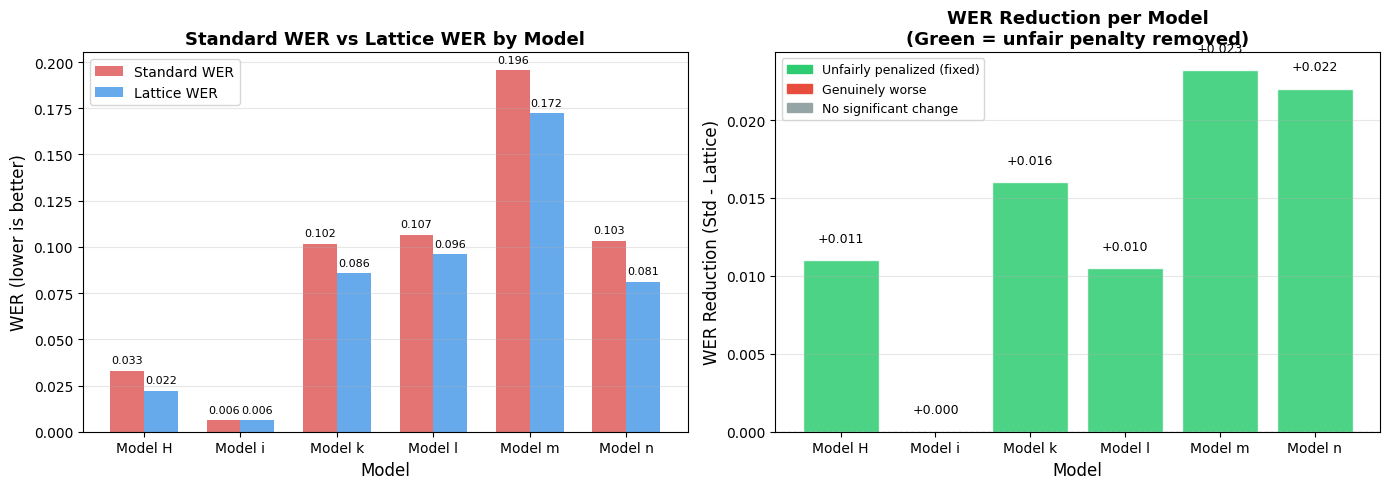

Chart saved as 'lattice_wer_comparison.png'


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

models = [r['Model'] for r in summary_rows]
std_vals = [float(r['Standard WER']) for r in summary_rows]
lat_vals = [float(r['Lattice WER']) for r in summary_rows]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Grouped bar chart
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, std_vals, width, label='Standard WER', color='#E05C5C', alpha=0.85)
bars2 = ax1.bar(x + width/2, lat_vals, width, label='Lattice WER', color='#4C9BE8', alpha=0.85)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('WER (lower is better)', fontsize=12)
ax1.set_title('Standard WER vs Lattice WER by Model', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Delta (improvement)
ax2 = axes[1]
deltas = [s - l for s, l in zip(std_vals, lat_vals)]
colors = ['#2ecc71' if d > 0.01 else ('#e74c3c' if d < -0.005 else '#95a5a6') for d in deltas]
bars3 = ax2.bar(models, deltas, color=colors, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('WER Reduction (Std - Lattice)', fontsize=12)
ax2.set_title('WER Reduction per Model\n(Green = unfair penalty removed)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, d in zip(bars3, deltas):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001 if d >= 0 else bar.get_height() - 0.005,
             f'{d:+.3f}', ha='center', va='bottom', fontsize=9)

green_patch = mpatches.Patch(color='#2ecc71', label='Unfairly penalized (fixed)')
red_patch = mpatches.Patch(color='#e74c3c', label='Genuinely worse')
grey_patch = mpatches.Patch(color='#95a5a6', label='No significant change')
ax2.legend(handles=[green_patch, red_patch, grey_patch], fontsize=9)

plt.tight_layout()
plt.savefig('lattice_wer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'lattice_wer_comparison.png'")

In [12]:
detail_df = pd.DataFrame(utterance_details)

print("=" * 80)
print("QUALITATIVE EXAMPLES: Where Lattice WER Differs from Standard WER")
print("=" * 80)

shown = 0
for idx, row in df.iterrows():
    ref_norm = row['ref_norm']
    ref_words = ref_norm.split()
    all_model_words = [row[f'{c}_norm'].split() for c in MODEL_COLS]
    lattice, agreed_ins = build_lattice(ref_words, all_model_words)

    # Check if any bin has valid alternatives
    interesting_bins = [(i, b) for i, b in enumerate(lattice)
                        if len(b['valid_words']) > 1 or b['optional']]

    if interesting_bins and shown < 5:
        print(f"\n--- Utterance {idx} ---")
        print(f"Reference: {ref_norm}")
        print("Lattice bins with alternatives:")
        for pos, bin_ in interesting_bins[:4]:
            alts = bin_['valid_words'] - {bin_['ref_word']}
            opt = " [OPTIONAL - majority deleted]" if bin_['optional'] else ""
            if alts:
                print(f"  Position {pos}: ref='{bin_['ref_word']}' | valid also: {alts}{opt}")
            else:
                print(f"  Position {pos}: ref='{bin_['ref_word']}'{opt}")

        # Show WER impact for Model k (often most different)
        for col in MODEL_COLS:
            hyp = row[f'{col}_norm']
            s_wer = compute_wer(ref_norm, hyp)
            l_wer = compute_lattice_wer(lattice, agreed_ins, hyp)
            if abs(s_wer - l_wer) > 0.05:
                print(f"  {col}: Std WER={s_wer:.3f} → Lattice WER={l_wer:.3f}  (Δ={s_wer-l_wer:+.3f})")
                print(f"    Hyp: {hyp}")
        shown += 1

if shown == 0:
    print("No strong differences found — try lowering AGREEMENT_THRESHOLD to 2.")

QUALITATIVE EXAMPLES: Where Lattice WER Differs from Standard WER

--- Utterance 6 ---
Reference: सर आपकी इच्छा जय सियाराम
Lattice bins with alternatives:
  Position 4: ref='सियाराम' | valid also: {'आराम'}
  Model H: Std WER=0.400 → Lattice WER=0.200  (Δ=+0.200)
    Hyp: सर आपकी इच्छा जय श्री आराम
  Model m: Std WER=0.400 → Lattice WER=0.200  (Δ=+0.200)
    Hyp: सर आपकी इच्छा जैसी आराम
  Model n: Std WER=0.400 → Lattice WER=0.200  (Δ=+0.200)
    Hyp: सर आपकी इच्छा जय सी आराम

--- Utterance 10 ---
Reference: हम्म बहुत प्योर हार्ट रहता है सबका
Lattice bins with alternatives:
  Position 0: ref='हम्म' [OPTIONAL - majority deleted]
  Model H: Std WER=0.143 → Lattice WER=0.000  (Δ=+0.143)
    Hyp: बहुत प्योर हार्ट रहता है सबका
  Model k: Std WER=0.429 → Lattice WER=0.286  (Δ=+0.143)
    Hyp: बहुत pure heart रहता है सबका
  Model l: Std WER=0.286 → Lattice WER=0.143  (Δ=+0.143)
    Hyp: बहुत पूरे हार्ट रहता है सबका
  Model m: Std WER=0.286 → Lattice WER=0.143  (Δ=+0.143)
    Hyp: बहुत प्योर हा

In [13]:
# Show per-utterance table for all models
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

display_cols = ['utterance_id', 'reference'] + \
    [f'{c}_std_wer' for c in MODEL_COLS] + \
    [f'{c}_lat_wer' for c in MODEL_COLS]

print("Per-Utterance WER Table (Standard | Lattice):")
detail_df[display_cols].head(20)

Per-Utterance WER Table (Standard | Lattice):


,utterance_id,reference,Model H_std_wer,Model i_std_wer,Model k_std_wer,Model l_std_wer,Model m_std_wer,Model n_std_wer,Model H_lat_wer,Model i_lat_wer,Model k_lat_wer,Model l_lat_wer,Model m_lat_wer,Model n_lat_wer
0,0,वही अपना खेती बाड़ी और क्या,0.0000,0.1667,0.0000,0.0000,0.3333,0.0000,0.0000,0.1667,0.0000,0.0000,0.3333,0.0000
1,1,मौनता का अर्थ क्या होता है,0.0000,0.0000,1.0000,0.3333,1.0000,0.3333,0.0000,0.0000,1.0000,0.3333,1.0000,0.3333
2,2,और रक्षाबंधन पे चलो बहनों को,0.0000,0.0000,0.0000,0.0000,0.3333,0.3333,0.0000,0.0000,0.0000,0.0000,0.3333,0.3333
3,3,एक सिंपल और सादा वे में,0.0000,0.0000,0.0000,0.3333,0.0000,0.0000,0.0000,0.0000,0.0000,0.3333,0.0000,0.0000
4,4,आने वाली चुनौतियों का इंतजार करना,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,5,अचानक आई मुश्किलों का सामना करना,0.0000,0.0000,0.0000,0.0000,0.8333,0.1667,0.0000,0.0000,0.0000,0.0000,0.8333,0.1667
6,6,सर आपकी इच्छा जय सियाराम,0.4000,0.0000,0.6000,0.4000,0.4000,0.4000,0.2000,0.0000,0.6000,0.4000,0.2000,0.2000
7,7,जी फीडबैक मिलने पर सुधार करना,0.0000,0.0000,0.1667,0.3333,0.0000,0.1667,0.0000,0.0000,0.1667,0.3333,0.0000,0.1667
8,8,जो एक महत्वपूर्ण भूमिका निभाते हैं,0.0000,0.0000,0.0000,0.0000,0.1667,0.0000,0.0000,0.0000,0.0000,0.0000,0.1667,0.0000
9,9,जीवन की चुनौतियों का सामना करना,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [14]:
# Export full per-utterance results
detail_df.to_csv('q4_per_utterance_wer.csv', index=False)
summary_df.to_csv('q4_summary_wer.csv', index=False)

print("Files saved:")
print("  q4_per_utterance_wer.csv  — per utterance standard + lattice WER")
print("  q4_summary_wer.csv        — final summary table")
print("  lattice_wer_comparison.png — comparison chart")

# Download
from google.colab import files
files.download('q4_per_utterance_wer.csv')
files.download('q4_summary_wer.csv')
files.download('lattice_wer_comparison.png')

Files saved:
  q4_per_utterance_wer.csv  — per utterance standard + lattice WER
  q4_summary_wer.csv        — final summary table
  lattice_wer_comparison.png — comparison chart


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
thresholds = [2, 3, 4, 5]
sensitivity_results = []

for thresh in thresholds:
    row_data = {'Threshold': thresh}
    for col in MODEL_COLS:
        lat_wers = []
        for idx, row in df.iterrows():
            ref_norm = row['ref_norm']
            ref_words = ref_norm.split()
            all_model_words = [row[f'{c}_norm'].split() for c in MODEL_COLS]
            lattice, agreed_ins = build_lattice(ref_words, all_model_words, threshold=thresh)
            hyp = row[f'{col}_norm']
            lat_wers.append(compute_lattice_wer(lattice, agreed_ins, hyp))
        row_data[f'{col}_lat_wer'] = round(np.mean(lat_wers), 4)
    sensitivity_results.append(row_data)

sens_df = pd.DataFrame(sensitivity_results)
print("=== Sensitivity Analysis: Lattice WER vs Agreement Threshold ===")
print(sens_df.to_string(index=False))
print("\nInterpretation:")
print("  Lower threshold → more alternatives in lattice → WER decreases more aggressively")
print("  Higher threshold → stricter consensus needed → conservative WER reduction")
print("  Recommended: threshold=3 (majority of 6 models) balances fairness and rigor")

=== Sensitivity Analysis: Lattice WER vs Agreement Threshold ===
 Threshold  Model H_lat_wer  Model i_lat_wer  Model k_lat_wer  Model l_lat_wer  Model m_lat_wer  Model n_lat_wer
         2           0.0175           0.0045           0.0680           0.0829           0.1497           0.0655
         3           0.0221           0.0061           0.0858           0.0961           0.1724           0.0812
         4           0.0282           0.0061           0.0919           0.0986           0.1858           0.0933
         5           0.0300           0.0061           0.0987           0.1035           0.1925           0.1001

Interpretation:
  Lower threshold → more alternatives in lattice → WER decreases more aggressively
  Higher threshold → stricter consensus needed → conservative WER reduction
  Recommended: threshold=3 (majority of 6 models) balances fairness and rigor
